In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load cleaned dataset

df = pd.read_csv("../processed/cleaned_youtube_data.csv")

df.head()

,category_id,view_count,like_count,comment_count,duration,duration_seconds
0,0.634019,0.029288,243350.0,-0.330080,PT57S,-0.329112
1,0.017250,-0.319920,3393.0,-0.165235,PT7M50S,0.044432
2,0.634019,2.944978,4178447.0,1.003008,PT47S,-0.338157
3,0.428429,0.524317,909386.0,0.162410,PT31S,-0.352628
4,0.634019,-0.219222,44278.0,-0.138177,PT16S,-0.366195


In [3]:
X = df[["view_count"]]

y = df["like_count"]

print("Feature Head :", X.head())
print("Target Head :", y.head())

Feature Head :    view_count
0    0.029288
1   -0.319920
2    2.944978
3    0.524317
4   -0.219222
Target Head : 0     243350.0
1       3393.0
2    4178447.0
3     909386.0
4      44278.0
Name: like_count, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 467
Testing Samples : 117


In [5]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

print("Original Shape :", X_train.shape)
print("Polynomial Shape :", X_train_poly.shape)

Original Shape : (467, 1)
Polynomial Shape : (467, 4)


In [6]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

print("Polynomial Regression model trained successfully.")

Polynomial Regression model trained successfully.


In [7]:
print("Intercept:", model.intercept_)

feature_names = poly.get_feature_names_out(["view_count"])

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

display(coefficients)

Intercept: 266780.6313195677


,Feature,Coefficient
0,1,0.000000
1,view_count,709842.043661
2,view_count^2,-69125.303512
3,view_count^3,1915.951832


In [8]:
y_pred = model.predict(X_test_poly)

y_pred[:10]

array([ 59395.974265  ,  24640.70163191,  75471.3829175 ,  56541.89714547,
        23901.92309206, 143915.14543839, 735957.40075472,  25064.35257286,
        38717.67791962,  37133.70446503])

In [9]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 145168.11531141863
Mean Squared Error : 133133500730.22668
Root Mean Squared Error : 364874.637005954
R² Score : 0.6986931023785226


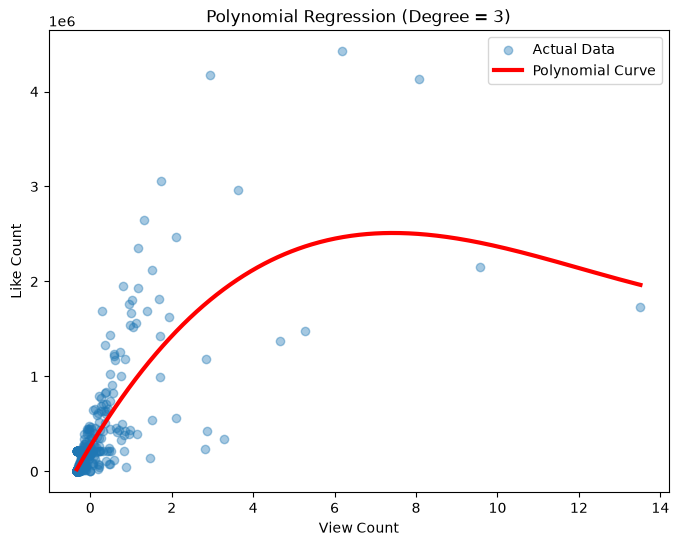

In [10]:
X_plot = pd.DataFrame({
    "view_count": np.linspace(
        X["view_count"].min(),
        X["view_count"].max(),
        500
    )
})

X_plot_poly = poly.transform(X_plot)

y_plot = model.predict(X_plot_poly)

plt.figure(figsize=(8,6))

plt.scatter(
    X["view_count"],
    y,
    alpha=0.4,
    label="Actual Data"
)

plt.plot(
    X_plot,
    y_plot,
    color="red",
    linewidth=3,
    label="Polynomial Curve"
)

plt.xlabel("View Count")
plt.ylabel("Like Count")
plt.title("Polynomial Regression (Degree = 3)")
plt.legend()

plt.savefig("../images/polynomial_regression.png", dpi=300)

plt.show()

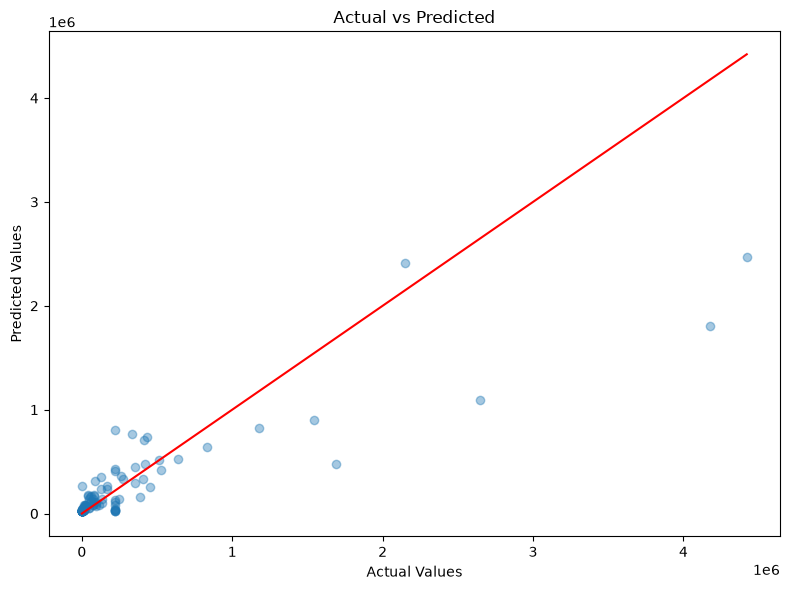

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

min_val = min(y_test.min(), y_pred.min())

max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red"
)

plt.tight_layout()

plt.savefig(
    "../images/polynomial_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    {
        "model": model,
        "poly": poly
    },
    "../models/polynomial_regression.pkl"
)

print("Polynomial model saved successfully.")

Polynomial model saved successfully.


## Conclusion

A Polynomial Regression model with degree 3 was developed using view_count as the predictor variable.

### Model Performance

Mean Absolute Error : 145168.11531141863
Mean Squared Error : 133133500730.22668
Root Mean Squared Error : 364874.637005954
R² Score : 0.6986931023785226

### Interpretation

Polynomial Regression allows the model to capture non-linear relationships between the number of views and the number of likes.

The performance of this model will be compared with the Simple Linear Regression and Multiple Linear Regression models in the next notebook to identify the best-performing approach.